# SIT307 8.1D - Sydney Housing Price Prediction and Decision Support System

## Part 1 - Problem Definition and Data Collection

The aim of this project is to develop a machine learning model that can predict
the sale price of residential properties in selected Sydney suburbs.

The project focuses on three suburbs with different housing market
characteristics:

- St Clair
- Baulkham Hills
- St Ives

A working dataset of 120 house sales is used, containing 40 properties from
each suburb. The dataset includes property characteristics, suburb information,
economic indicators and the final sale price.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/SIT307_8.1D_project_housing_120.csv")

df.head()

,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,640000,13/7/16,St Clair,1,3,6,574,House,19897,38896,7.204,-33.79794,150.78794,59,1.75,159.3,39.76
1,721000,20/7/16,St Clair,3,4,1,629,House,19897,38896,7.204,-33.79794,150.78794,59,1.75,159.3,39.76
2,580000,28/7/16,St Clair,1,3,2,627,House,19897,38896,7.204,-33.79794,150.78794,59,1.75,159.3,39.76
3,850000,16/8/16,St Clair,3,5,4,672,House,19897,38896,7.204,-33.79794,150.78794,59,1.52,159.3,39.76
4,720000,8/10/16,St Clair,2,4,2,800,House,19897,38896,7.204,-33.79794,150.78794,59,1.52,159.3,39.76


In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (120, 17)

Columns:
['price', 'date_sold', 'suburb', 'num_bath', 'num_bed', 'num_parking', 'property_size', 'type', 'suburb_population', 'suburb_median_income', 'suburb_sqkm', 'suburb_lat', 'suburb_lng', 'suburb_elevation', 'cash_rate', 'property_inflation_index', 'km_from_cbd']


In [3]:
df["suburb"].value_counts()

suburb
St Clair          40
Baulkham Hills    40
St Ives           40
Name: count, dtype: int64

The dataset contains 120 properties in total, with 40 observations from each
of the three selected suburbs. This provides a balanced representation of the
three housing markets and exceeds the minimum requirement of 30 properties
per suburb.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     120 non-null    int64  
 1   date_sold                 120 non-null    str    
 2   suburb                    120 non-null    str    
 3   num_bath                  120 non-null    int64  
 4   num_bed                   120 non-null    int64  
 5   num_parking               120 non-null    int64  
 6   property_size             120 non-null    int64  
 7   type                      120 non-null    str    
 8   suburb_population         120 non-null    int64  
 9   suburb_median_income      120 non-null    int64  
 10  suburb_sqkm               120 non-null    float64
 11  suburb_lat                120 non-null    float64
 12  suburb_lng                120 non-null    float64
 13  suburb_elevation          120 non-null    int64  
 14  cash_rate            

### Available Features

The prediction target is `price`.

The dataset contains several groups of potential predictor variables:

- Property characteristics: bedrooms, bathrooms, parking spaces and property size.
- Location information: suburb, latitude, longitude and distance from the CBD.
- Suburb characteristics: population, median income, area and elevation.
- Economic and temporal information: sale date, cash rate and property inflation index.

These variables provide information about both the individual property and the
broader location and economic environment in which it was sold.

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
price                       0
date_sold                   0
suburb                      0
num_bath                    0
num_bed                     0
num_parking                 0
property_size               0
type                        0
suburb_population           0
suburb_median_income        0
suburb_sqkm                 0
suburb_lat                  0
suburb_lng                  0
suburb_elevation            0
cash_rate                   0
property_inflation_index    0
km_from_cbd                 0
dtype: int64

Duplicate rows: 0


In [6]:
print(df["type"].value_counts())

type
House    120
Name: count, dtype: int64


### Initial Data Quality Check

The initial dataset contains no missing values and no duplicate rows. All
properties in the selected sample are classified as houses, which keeps the
property type consistent across the three suburbs.

While this consistency can make comparisons between suburbs clearer, it also
means that the developed model will mainly be applicable to houses and should
not automatically be assumed to perform well for apartments, units or
townhouses.

In [7]:
df["date_sold"] = pd.to_datetime(
    df["date_sold"],
    format="%d/%m/%y"
)

print("Earliest sale:", df["date_sold"].min())
print("Latest sale:", df["date_sold"].max())

Earliest sale: 2016-07-13 00:00:00
Latest sale: 2021-12-23 00:00:00


The property sales in the working dataset range from July 2016 to December
2021. Housing market conditions can change significantly over time, so the age
of the observations is an important limitation when interpreting predictions
for the current Sydney property market.

### Suburb Selection

The three suburbs were selected because they represent noticeably different
housing markets.

- **St Clair** represents the comparatively lower-priced market in the working
dataset and is located farther from the Sydney CBD.

- **Baulkham Hills** represents a middle-to-higher priced suburban housing market
and is located closer to the CBD than St Clair.

- **St Ives** represents the highest-priced market among the three selected
suburbs and is also the closest to the CBD in this dataset.

Using suburbs with different locations and property price levels allows the
project to investigate whether a machine learning model can capture differences
between distinct Sydney housing markets.

### Dataset Source and Selection

The original Sydney housing dataset was obtained from the
**Sydney House Prices** dataset published by Alex Lau on Kaggle.

For this project, three suburbs were selected and a balanced working sample
of 120 house sales was created, containing 40 properties from St Clair,
Baulkham Hills and St Ives.

The dataset contains property-level characteristics together with suburb and
economic information that can be investigated for housing price prediction.

### Data Quality, Bias and Limitations

The dataset provides a balanced number of properties across the three selected
suburbs and contains no missing or duplicate observations in the current sample.

However, several limitations should be considered. The dataset only contains
houses, so the results may not generalise to other property types such as units
or townhouses. The selected suburbs also represent only a small portion of the
Sydney housing market.

The sales occurred between 2016 and 2021, meaning that the data may not fully
represent current property market conditions. Changes in interest rates,
inflation, buyer demand and local development may affect current prices.

Some important factors affecting property value may also be unavailable,
including property condition, renovation quality, street appeal, views,
proximity to schools and transport, and detailed interior characteristics.
These limitations may contribute to prediction errors later in the project.

## Part 2 - Data Understanding and Feature Engineering

In this section, the dataset is explored to better understand housing price
patterns, differences between suburbs, changes over time and unusual
observations. Potential feature engineering opportunities are then considered
before model development.

### Initial Expectations of Important Variables

Before performing feature engineering, I expect the following three variables
to have the strongest influence on house prices:

1. **Suburb** - Location is expected to have a major influence because the three
   suburbs represent different housing markets, accessibility levels and
   surrounding neighbourhood characteristics.

2. **Property size** - Larger properties generally provide more land and usable
   space, which is expected to increase their market value.

3. **Number of bedrooms** - The number of bedrooms reflects the capacity and
   suitability of a house for different households, so properties with more
   bedrooms may generally attract higher prices.

These are initial expectations and will later be compared with the patterns
observed in the data and the behaviour of the trained models.

In [8]:
eda_columns = [
    "price",
    "num_bed",
    "num_bath",
    "num_parking",
    "property_size",
    "km_from_cbd",
    "cash_rate",
    "property_inflation_index"
]

df[eda_columns].describe().round(2)

,price,num_bed,num_bath,num_parking,property_size,km_from_cbd,cash_rate,property_inflation_index
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,1775092.50,4.17,2.22,2.55,881.01,26.85,0.62,186.18
std,1051163.33,0.89,1.01,1.36,472.18,9.85,0.61,23.25
min,580000.00,3.00,0.00,0.00,300.00,15.99,0.10,159.00
25%,1018250.00,3.75,2.00,2.00,667.75,15.99,0.10,166.55
50%,1582500.00,4.00,2.00,2.00,784.00,24.81,0.11,172.60
75%,2236500.00,5.00,3.00,3.00,931.25,39.76,1.00,220.10
max,5900000.00,7.00,6.00,8.00,4998.00,39.76,1.75,220.10


The descriptive statistics show a wide range of property prices. The overall
mean price is higher than the median price, suggesting that some expensive
properties are pulling the average upward. Property characteristics such as
size, bedrooms, bathrooms and parking spaces also vary across the sample.

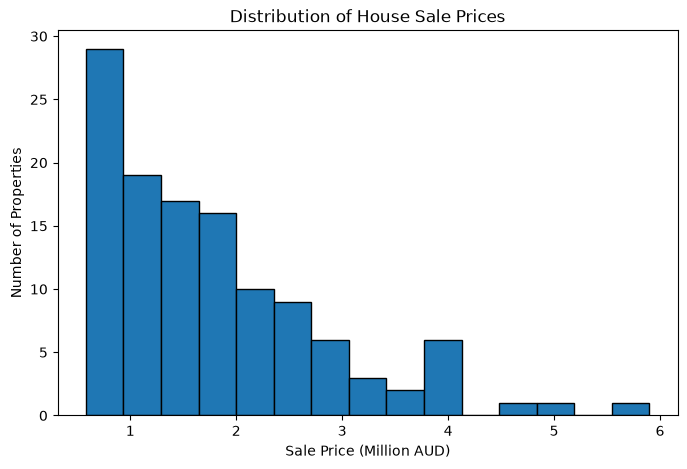

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["price"] / 1_000_000, bins=15, edgecolor="black")

plt.xlabel("Sale Price (Million AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of House Sale Prices")

plt.savefig(
    "../reports/figures/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The price distribution is not completely symmetrical. Most properties are
concentrated in the lower and middle price ranges, while a smaller number of
high-value properties extend the distribution towards the upper end.

This explains why the mean sale price is higher than the median and indicates
that expensive properties may have a noticeable influence on model training.

In [10]:
suburb_price_summary = (
    df.groupby("suburb")["price"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(0)
)

suburb_price_summary

,count,mean,median,min,max
suburb,,,,,
Baulkham Hills,40,1635052.0,1592500.0,1070000,2709000
St Clair,40,821350.0,745000.0,580000,1300000
St Ives,40,2868875.0,2663500.0,1420000,5900000


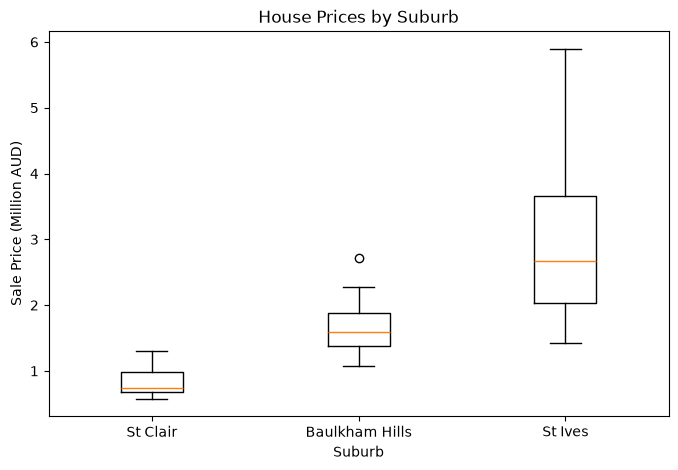

In [39]:
suburb_order = ["St Clair", "Baulkham Hills", "St Ives"]

price_groups = [
    df.loc[df["suburb"] == suburb, "price"] / 1_000_000
    for suburb in suburb_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(price_groups, tick_labels=suburb_order)

plt.ylabel("Sale Price (Million AUD)")
plt.xlabel("Suburb")
plt.title("House Prices by Suburb")

plt.savefig(
    "../reports/figures/suburb_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

There are clear differences in property prices between the three suburbs.
St Clair has the lowest overall price level, Baulkham Hills represents the
middle range, and St Ives has substantially higher prices.

The variation within each suburb also differs. In particular, St Ives contains
a wider range of expensive properties. This supports the initial expectation
that suburb/location will be an important predictor of sale price.

In [12]:
yearly_price = (
    df.assign(sale_year=df["date_sold"].dt.year)
      .groupby(["sale_year", "suburb"])["price"]
      .median()
      .unstack()
)

yearly_price

suburb,Baulkham Hills,St Clair,St Ives
sale_year,,,
2016,NaN,720000.0,2125000.0
2017,NaN,730000.0,NaN
2018,NaN,680000.0,2295000.0
2019,1313050.0,650000.0,2223000.0
2020,1289500.0,750000.0,2800000.0
2021,1862500.0,1085750.0,3010000.0


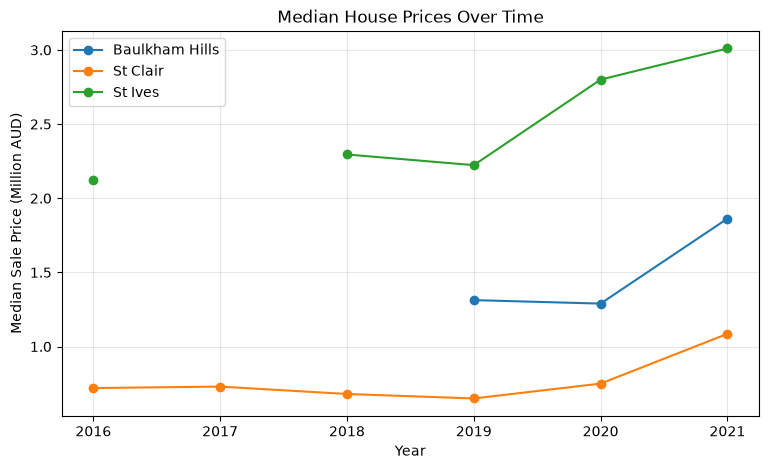

In [40]:
plt.figure(figsize=(9, 5))

for suburb in yearly_price.columns:
    plt.plot(
        yearly_price.index,
        yearly_price[suburb] / 1_000_000,
        marker="o",
        label=suburb
    )

plt.xlabel("Year")
plt.ylabel("Median Sale Price (Million AUD)")
plt.title("Median House Prices Over Time")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../reports/figures/price_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The yearly median prices suggest that housing prices changed over the period
covered by the dataset, although the pattern differs between suburbs.

The later years generally contain higher prices, particularly during 2021.
However, these trends should be interpreted cautiously because the number of
properties available for each suburb is not equal across every year. Therefore,
the graph represents the sampled properties rather than the complete Sydney
housing market.

In [14]:
outlier_rows = []

for suburb, group in df.groupby("suburb"):
    
    Q1 = group["price"].quantile(0.25)
    Q3 = group["price"].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    suburb_outliers = group[
        (group["price"] < lower_bound) |
        (group["price"] > upper_bound)
    ].copy()
    
    outlier_rows.append(suburb_outliers)

price_outliers = pd.concat(outlier_rows)

price_outliers[
    [
        "suburb",
        "price",
        "num_bed",
        "num_bath",
        "num_parking",
        "property_size"
    ]
]

,suburb,price,num_bed,num_bath,num_parking,property_size
68,Baulkham Hills,2709000,5,3,4,988


The IQR method was applied separately within each suburb because the three
suburbs have substantially different normal price ranges.

A small number of unusually priced observations were identified. These
properties are not automatically treated as errors, because unusually expensive
or large houses may represent genuine sales. Instead, they will be retained
unless there is evidence that the values are incorrect.

These unusual properties may also be useful later when investigating cases
where the machine learning model produces large prediction errors.

In [15]:
df[
    [
        "num_bed",
        "num_bath",
        "num_parking",
        "property_size"
    ]
].describe()

,num_bed,num_bath,num_parking,property_size
count,120.000000,120.000000,120.000000,120.000000
mean,4.166667,2.225000,2.550000,881.008333
std,0.891918,1.008056,1.358756,472.180807
min,3.000000,0.000000,0.000000,300.000000
25%,3.750000,2.000000,2.000000,667.750000
50%,4.000000,2.000000,2.000000,784.000000
75%,5.000000,3.000000,3.000000,931.250000
max,7.000000,6.000000,8.000000,4998.000000


In [16]:
df.nlargest(
    10,
    "property_size"
)[
    [
        "suburb",
        "price",
        "num_bed",
        "num_bath",
        "num_parking",
        "property_size"
    ]
]

,suburb,price,num_bed,num_bath,num_parking,property_size
104,St Ives,2000000,5,4,3,4998
84,St Ives,3340000,5,4,2,1941
41,Baulkham Hills,1410000,5,2,3,1914
88,St Ives,2750000,4,2,2,1752
92,St Ives,2890000,4,2,2,1745
83,St Ives,3100000,4,3,4,1695
64,Baulkham Hills,2271000,5,3,6,1606
95,St Ives,1800000,4,2,2,1593
118,St Ives,5900000,5,6,2,1442
116,St Ives,3900000,4,2,2,1163


Some properties have substantially larger land sizes than the majority of the
sample. These observations may represent genuine large residential blocks
rather than incorrect data.

Such extreme property characteristics could influence model performance,
particularly for models that are sensitive to unusually large numerical values.

In [17]:
numeric_correlations = (
    df.select_dtypes(include="number")
      .corr()["price"]
      .sort_values(ascending=False)
)

numeric_correlations

price                       1.000000
suburb_elevation            0.800675
suburb_lng                  0.797341
suburb_median_income        0.793456
suburb_lat                  0.754811
suburb_sqkm                 0.543161
num_bath                    0.536266
num_bed                     0.450199
property_size               0.339974
property_inflation_index    0.278759
num_parking                -0.060125
suburb_population          -0.190524
cash_rate                  -0.274143
km_from_cbd                -0.775909
Name: price, dtype: float64

The correlation values provide an initial indication of how numerical variables
are associated with sale price. However, correlation alone does not determine
which variables will be most useful to a predictive model.

Some suburb-level variables also take only three different values because they
are fixed for each suburb. Therefore, their correlation with price may partly
reflect the differences between the three suburbs rather than an independent
effect.

In [18]:
df.nunique().sort_values()

type                          1
suburb                        3
suburb_elevation              3
suburb_lng                    3
suburb_lat                    3
suburb_sqkm                   3
suburb_median_income          3
suburb_population             3
km_from_cbd                   3
num_bed                       5
num_bath                      6
cash_rate                     8
num_parking                   9
property_inflation_index     13
property_size                78
date_sold                    88
price                       103
dtype: int64

In [19]:
# Year in which the property was sold
df["sale_year"] = df["date_sold"].dt.year

# Approximate property size available per bedroom
df["size_per_bedroom"] = (
    df["property_size"] / df["num_bed"]
)

df[
    [
        "date_sold",
        "sale_year",
        "property_size",
        "num_bed",
        "size_per_bedroom"
    ]
].head()

,date_sold,sale_year,property_size,num_bed,size_per_bedroom
0,2016-07-13,2016,574,3,191.333333
1,2016-07-20,2016,629,4,157.250000
2,2016-07-28,2016,627,3,209.000000
3,2016-08-16,2016,672,5,134.400000
4,2016-10-08,2016,800,4,200.000000


### Engineered Features

Two additional features were created.

- **Sale year** was extracted from the sale date to allow the model to capture
changes in the housing market over time. Using the raw date directly would be
less suitable for most regression algorithms.

- **Size per bedroom** was calculated by dividing property size by the number of
bedrooms. This provides an indication of how much property space is available
relative to the accommodation capacity of the house.

The feature engineering decisions remain consistent with the initial
expectations. Property size and bedroom count were initially expected to be
important, while the exploration of prices over time showed that the year of
sale may also contain useful information.

A feature such as price per square metre was not used as a predictor because it
would require the actual sale price to calculate it. Since sale price is the
target being predicted, using such a feature would introduce target leakage and
produce unrealistically optimistic model performance.

In [20]:
# Check potentially unrealistic zero values

zero_bathrooms = df[df["num_bath"] == 0]

zero_parking = df[df["num_parking"] == 0]

print("Properties with 0 bathrooms:")
display(
    zero_bathrooms[
        [
            "suburb",
            "price",
            "num_bed",
            "num_bath",
            "num_parking",
            "property_size",
            "date_sold"
        ]
    ]
)

print("\nProperties with 0 parking spaces:")
display(
    zero_parking[
        [
            "suburb",
            "price",
            "num_bed",
            "num_bath",
            "num_parking",
            "property_size",
            "date_sold"
        ]
    ]
)

Properties with 0 bathrooms:


,suburb,price,num_bed,num_bath,num_parking,property_size,date_sold
71,Baulkham Hills,1850000,5,0,2,766,2021-12-17
72,Baulkham Hills,1916000,4,0,2,755,2021-12-18
73,Baulkham Hills,2100000,4,0,2,750,2021-12-18
75,Baulkham Hills,1675000,5,0,2,771,2021-12-18



Properties with 0 parking spaces:


,suburb,price,num_bed,num_bath,num_parking,property_size,date_sold
21,St Clair,610000,3,1,0,635,2019-11-09


### Additional Data Quality Check

Although the dataset contains no formally missing values, some variables contain
zero values that may represent unavailable information rather than genuine
property characteristics.

Four properties have zero recorded bathrooms, which is unlikely for residential
houses and may indicate missing or incomplete information in the original data.
One property has zero recorded parking spaces, which is more plausible because
some houses may not include dedicated parking.  
The zero-bathroom observations therefore need to be considered during
preprocessing before model training.

## Part 3 - Model Development and Evaluation

In this section, three regression models are developed and compared using
5-fold cross-validation. The models represent different modelling approaches
so that both simple linear relationships and more complex nonlinear patterns
can be investigated.

The models selected are:

1. Ridge Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

### Model Selection and Initial Expectations

- **Ridge Regression** was selected as a regularised linear model and will provide
a relatively simple baseline. It is useful for identifying whether housing
prices can be explained reasonably well through mostly linear relationships.
However, it may underfit if relationships between property characteristics and
price are strongly nonlinear.

- **Random Forest Regressor** was selected because it can model nonlinear
relationships and interactions between features without requiring these
relationships to be specified manually. It is also relatively robust to
outliers, although a complex forest may overfit a small dataset.

- **Gradient Boosting Regressor** was selected as a boosting-based ensemble
approach. It builds trees sequentially, with later trees focusing on errors
made by earlier trees. This can provide strong predictive performance on
structured tabular data, although excessive model complexity can also lead
to overfitting.

Before training the models, I expect Gradient Boosting to achieve the best
validation performance because housing prices are likely to depend on
nonlinear relationships and interactions between location, property size,
rooms and market conditions. Random Forest is also expected to perform well,
while Ridge Regression may provide a useful but less flexible baseline.

In [21]:
import numpy as np

# Create a separate dataframe for modelling
model_df = df.copy()

# Zero bathrooms are unlikely for residential houses.
# Treat these values as missing so they can be imputed inside the pipeline.
model_df.loc[model_df["num_bath"] == 0, "num_bath"] = np.nan

features = [
    "suburb",
    "num_bed",
    "num_bath",
    "num_parking",
    "property_size",
    "cash_rate",
    "property_inflation_index",
    "sale_year",
    "size_per_bedroom"
]

X = model_df[features]
y = model_df["price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (120, 9)
Target shape: (120,)


,suburb,num_bed,num_bath,num_parking,property_size,cash_rate,property_inflation_index,sale_year,size_per_bedroom
0,St Clair,3,1.0,6,574,1.75,159.3,2016,191.333333
1,St Clair,4,3.0,1,629,1.75,159.3,2016,157.250000
2,St Clair,3,1.0,2,627,1.75,159.3,2016,209.000000
3,St Clair,5,3.0,4,672,1.52,159.3,2016,134.400000
4,St Clair,4,2.0,2,800,1.52,159.3,2016,200.000000


### Feature Selection for Modelling

The modelling dataset uses property characteristics, suburb, economic
information and the engineered features created in Part 2.  
The raw `date_sold` variable is not used because `sale_year` has already been
extracted from it. The `type` variable is also excluded because every property
in the dataset is classified as a house, meaning that it contains no variation.

Several suburb-level variables such as population, latitude, longitude,
elevation and distance from the CBD are also excluded from the initial models.
Within this dataset, these values are fixed for each of the three suburbs and
therefore largely duplicate the information already represented by `suburb`.  
Zero bathroom values are treated as missing values because a residential house
with no bathroom is unlikely. These values will be imputed during preprocessing
rather than manually replaced before cross-validation.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "num_bed",
    "num_bath",
    "num_parking",
    "property_size",
    "cash_rate",
    "property_inflation_index",
    "sale_year",
    "size_per_bedroom"
]

categorical_features = ["suburb"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Preprocessing

Numerical variables are median-imputed where necessary and then standardised.
Median imputation is used because it is less affected by extreme values than
the mean.

The suburb variable is converted using one-hot encoding so that it can be used
by the regression algorithms without incorrectly implying an ordinal
relationship between the three suburb names.

Preprocessing is included inside the machine learning pipeline so that it is
fitted separately within each cross-validation training fold. This helps avoid
information leaking from validation data into model training.

In [23]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

models = {
    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [24]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Cross-Validation Strategy

Five-fold cross-validation is used to evaluate the models. The dataset is
divided into five folds, with each fold used once as validation data while the
remaining folds are used for training.

Shuffling is applied before creating the folds because the dataset was
originally grouped by suburb and sale date. A fixed random state is used so
that the results are reproducible.

### Evaluation Metrics

Three regression metrics are used:

- **Mean Absolute Error (MAE):** measures the average absolute difference
  between predicted and actual sale prices. Lower values are better.

- **Root Mean Squared Error (RMSE):** gives greater weight to large prediction
  errors, making it useful for identifying models that make occasional large
  mistakes. Lower values are better.

- **R² score:** measures the proportion of variation in sale prices explained
  by the model. Values closer to 1 indicate stronger predictive performance.

Using multiple metrics provides a more complete evaluation than relying on a
single performance measure.

In [25]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    results.append({
        "Model": model_name,

        "Train MAE":
            -scores["train_MAE"].mean(),

        "CV MAE":
            -scores["test_MAE"].mean(),

        "Train RMSE":
            np.sqrt(-scores["train_MSE"]).mean(),

        "CV RMSE":
            np.sqrt(-scores["test_MSE"]).mean(),

        "Train R2":
            scores["train_R2"].mean(),

        "CV R2":
            scores["test_R2"].mean()
    })


results_df = pd.DataFrame(results)

results_df.round(2)

,Model,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R2,CV R2
0,Ridge Regression,320475.06,404323.88,428388.04,593889.40,0.83,0.54
1,Random Forest,102299.47,283582.54,180238.82,479731.89,0.97,0.75
2,Gradient Boosting,51333.73,256317.86,75743.10,433286.01,0.99,0.79


In [26]:
comparison = results_df[
    [
        "Model",
        "CV MAE",
        "CV RMSE",
        "CV R2"
    ]
].copy()

comparison["CV MAE"] = comparison["CV MAE"].round(0)
comparison["CV RMSE"] = comparison["CV RMSE"].round(0)
comparison["CV R2"] = comparison["CV R2"].round(3)

comparison

,Model,CV MAE,CV RMSE,CV R2
0,Ridge Regression,404324.0,593889.0,0.541
1,Random Forest,283583.0,479732.0,0.749
2,Gradient Boosting,256318.0,433286.0,0.786


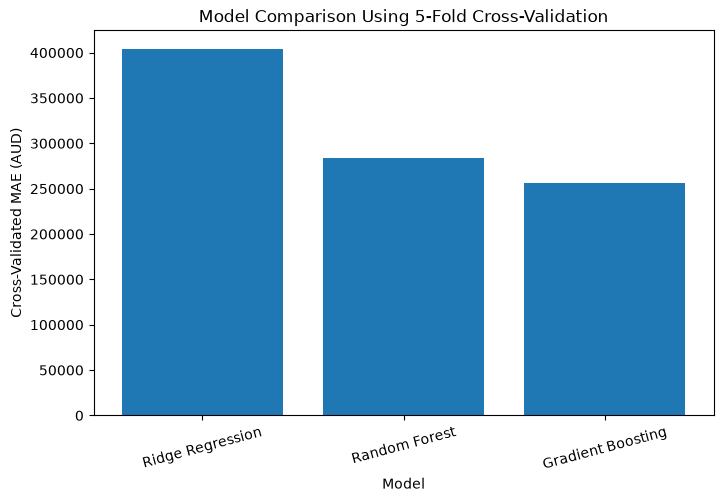

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["CV MAE"]
)

plt.ylabel("Cross-Validated MAE (AUD)")
plt.xlabel("Model")
plt.title("Model Comparison Using 5-Fold Cross-Validation")

plt.xticks(rotation=15)

plt.show()

In [28]:
overfit_comparison = results_df[
    [
        "Model",
        "Train MAE",
        "CV MAE",
        "Train R2",
        "CV R2"
    ]
].copy()

overfit_comparison.round(3)

,Model,Train MAE,CV MAE,Train R2,CV R2
0,Ridge Regression,320475.059,404323.881,0.831,0.541
1,Random Forest,102299.473,283582.544,0.970,0.749
2,Gradient Boosting,51333.731,256317.858,0.995,0.786


### Model Behaviour and Complexity

Ridge Regression produced the weakest cross-validation performance, with a
cross-validated R² of approximately 0.54 and the largest MAE and RMSE. Although
its training performance is reasonable, its lower validation performance
suggests that a linear model is not flexible enough to capture all of the
relationships affecting housing prices in this dataset.

Random Forest achieved much stronger validation performance, with a
cross-validated R² of approximately 0.75. However, its training R² of around
0.97 is noticeably higher than its validation R². The training MAE is also much
lower than the validation MAE, indicating that some overfitting is present.

Gradient Boosting achieved the strongest cross-validation performance, with the
lowest MAE and RMSE and the highest validation R² of approximately 0.79.
However, its training R² is almost 1.0 while its validation R² is lower, showing
that it also overfits the training data to some extent.

Overall, increasing model complexity improved validation performance, but it
also increased the gap between training and validation performance. This is an
important trade-off when working with a relatively small dataset of only 120
properties.

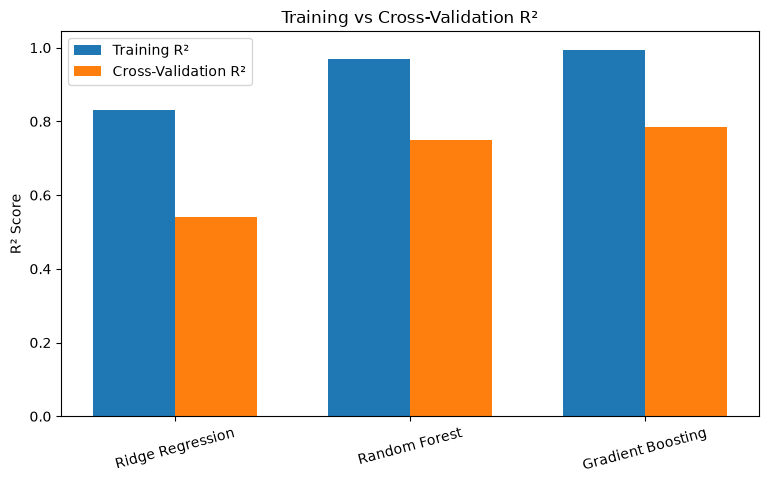

In [41]:
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    results_df["Train R2"],
    width,
    label="Training R²"
)

plt.bar(
    x + width / 2,
    results_df["CV R2"],
    width,
    label="Cross-Validation R²"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=15
)

plt.ylabel("R² Score")
plt.title("Training vs Cross-Validation R²")
plt.legend()

plt.savefig(
    "../reports/figures/train_vs_cv_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The comparison between training and cross-validation R² shows that the two
ensemble models fit the training data extremely well. However, their validation
scores are lower, indicating some loss of generalisation to unseen data.

Gradient Boosting has the largest training performance but still provides the
strongest validation result, suggesting that its additional complexity captures
useful patterns despite some overfitting.

### Revisiting the Initial Expectation

Before training the models, Gradient Boosting was expected to perform best
because housing prices are likely to depend on nonlinear relationships and
interactions between property, location and market features.

The experimental results support this expectation. Gradient Boosting achieved
the lowest cross-validated MAE of approximately $256,000, the lowest RMSE of
approximately $433,000 and the highest cross-validated R² of approximately
0.79.

Random Forest also performed substantially better than Ridge Regression,
further suggesting that nonlinear modelling approaches are more suitable for
this dataset.

### Final Model Selection

Gradient Boosting is selected as the final model for the remainder of the
project because it achieved the strongest cross-validation performance across
all three evaluation metrics.

Its average absolute prediction error is approximately $256,000, and it
explains around 79% of the variation in sale prices during cross-validation.
Although some overfitting is present, its validation performance remains better
than both Random Forest and Ridge Regression.

Because the dataset contains only 120 properties from three suburbs, the model
should still be considered a prototype rather than a general property valuation
model for the whole Sydney housing market.

In [30]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## Part 4 - Investigating Prediction Failures

This section investigates the properties for which the selected Gradient
Boosting model produced the largest prediction errors.

Out-of-fold predictions are used so that each property's prediction is produced
by a model that was not trained on that property. This provides a more realistic
view of prediction failure than evaluating predictions on the training data.

### 4.1 Generate out-of-fold predictions

In [31]:
from sklearn.model_selection import cross_val_predict

# Generate predictions for each property while it is held out
oof_predictions = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv
)

error_analysis = df.copy()

error_analysis["predicted_price"] = oof_predictions

# Positive value = model predicted too high
# Negative value = model predicted too low
error_analysis["prediction_error"] = (
    error_analysis["predicted_price"] - error_analysis["price"]
)

error_analysis["absolute_error"] = (
    error_analysis["prediction_error"].abs()
)

error_analysis["absolute_percentage_error"] = (
    error_analysis["absolute_error"] /
    error_analysis["price"] * 100
)

error_analysis["prediction_direction"] = np.where(
    error_analysis["prediction_error"] > 0,
    "Over-predicted",
    "Under-predicted"
)

error_analysis.head()

,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,...,cash_rate,property_inflation_index,km_from_cbd,sale_year,size_per_bedroom,predicted_price,prediction_error,absolute_error,absolute_percentage_error,prediction_direction
0,640000,2016-07-13,St Clair,1,3,6,574,House,19897,38896,...,1.75,159.3,39.76,2016,191.333333,617966.220151,-22033.779849,22033.779849,3.442778,Under-predicted
1,721000,2016-07-20,St Clair,3,4,1,629,House,19897,38896,...,1.75,159.3,39.76,2016,157.250000,709558.214336,-11441.785664,11441.785664,1.586933,Under-predicted
2,580000,2016-07-28,St Clair,1,3,2,627,House,19897,38896,...,1.75,159.3,39.76,2016,209.000000,629181.013416,49181.013416,49181.013416,8.479485,Over-predicted
3,850000,2016-08-16,St Clair,3,5,4,672,House,19897,38896,...,1.52,159.3,39.76,2016,134.400000,802941.310324,-47058.689676,47058.689676,5.536316,Under-predicted
4,720000,2016-10-08,St Clair,2,4,2,800,House,19897,38896,...,1.52,159.3,39.76,2016,200.000000,729561.920616,9561.920616,9561.920616,1.328045,Over-predicted


### 4.2 Find the five largest errors

In [32]:
top_5_errors = (
    error_analysis
    .nlargest(5, "absolute_error")
    .copy()
)

top_5_display = top_5_errors[
    [
        "suburb",
        "date_sold",
        "price",
        "predicted_price",
        "prediction_direction",
        "absolute_error",
        "absolute_percentage_error",
        "num_bed",
        "num_bath",
        "num_parking",
        "property_size"
    ]
].copy()

top_5_display["predicted_price"] = (
    top_5_display["predicted_price"].round(0)
)

top_5_display["absolute_error"] = (
    top_5_display["absolute_error"].round(0)
)

top_5_display["absolute_percentage_error"] = (
    top_5_display["absolute_percentage_error"].round(1)
)

top_5_display

,suburb,date_sold,price,predicted_price,prediction_direction,absolute_error,absolute_percentage_error,num_bed,num_bath,num_parking,property_size
104,St Ives,2021-02-18,2000000,4251920.0,Over-predicted,2251920.0,112.6,5,4,3,4998
106,St Ives,2021-02-19,5100000,2984157.0,Under-predicted,2115843.0,41.5,5,4,2,1024
118,St Ives,2021-11-24,5900000,4238571.0,Under-predicted,1661429.0,28.2,5,6,2,1442
110,St Ives,2021-02-27,2810000,3856708.0,Over-predicted,1046708.0,37.2,5,4,2,942
89,St Ives,2018-05-26,4020000,3097640.0,Under-predicted,922360.0,22.9,6,4,2,930


### 4.3 Compare them with a typical St Ives property

In [33]:
st_ives_reference = (
    df[df["suburb"] == "St Ives"]
    [
        [
            "price",
            "num_bed",
            "num_bath",
            "num_parking",
            "property_size"
        ]
    ]
    .median()
)

st_ives_reference

price            2663500.0
num_bed                5.0
num_bath               3.0
num_parking            2.0
property_size        942.0
dtype: float64

### 4.4 Visualise the five largest errors

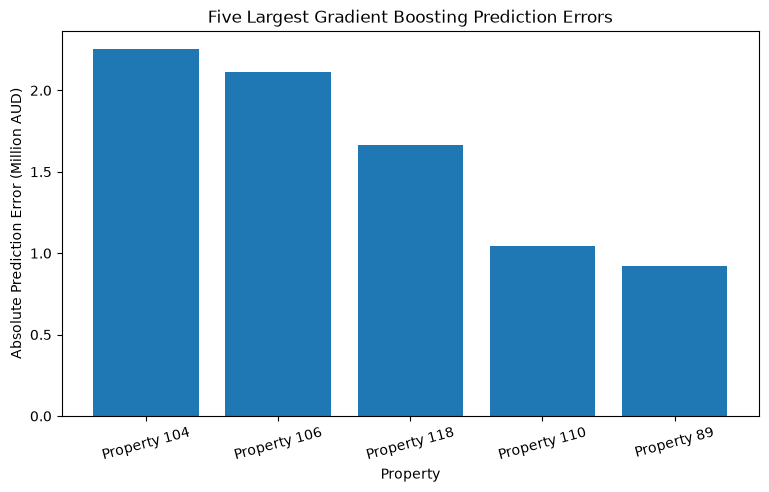

In [42]:
top_5_plot = top_5_errors.copy()

top_5_plot["Property"] = [
    f"Property {i}" for i in top_5_plot.index
]

plt.figure(figsize=(9, 5))

plt.bar(
    top_5_plot["Property"],
    top_5_plot["absolute_error"] / 1_000_000
)

plt.ylabel("Absolute Prediction Error (Million AUD)")
plt.xlabel("Property")
plt.title("Five Largest Gradient Boosting Prediction Errors")

plt.xticks(rotation=15)

plt.savefig(
    "../reports/figures/largest_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.5 Investigation of the Largest Prediction Errors

All five of the largest prediction errors occurred in St Ives, showing that the
model struggled more with the higher-value and more variable properties in this
suburb.

Property 104 had the largest error. It sold for $2.00 million but was predicted
at about $4.25 million. Its property size of 4,998 m² is much larger than the
St Ives median of 942 m², so the model may have placed too much importance on
land size.

Properties 106 and 118 were both strongly under-predicted. They sold for
$5.10 million and $5.90 million, but the model predicted about $2.98 million
and $4.24 million. These high-value properties are less common in the dataset,
so the model has fewer similar examples to learn from.

Properties 110 and 89 also produced large errors even though their basic
features were closer to typical St Ives properties. This suggests that the
available variables do not fully capture all factors affecting sale price.

Overall, the results show that unusual and high-value properties are harder to
predict. Important information such as property condition, renovation quality,
exact location and views is not included in the dataset and may help explain
these errors.

## Part 5 - Final Deployment and Reflection

### 5.1 Final Model Deployment

The selected Gradient Boosting pipeline is fitted using the complete dataset
and saved so that it can be loaded by the web application.

The model includes the same preprocessing steps used during evaluation,
ensuring that new user inputs are processed consistently before prediction.

In [35]:
import joblib
from pathlib import Path

# Fit the selected model on the complete dataset
best_model.fit(X, y)

# Save the trained pipeline
model_path = Path("../models/gradient_boosting_model.joblib")

joblib.dump(best_model, model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\gradient_boosting_model.joblib


### 5.2 Reflection on the Machine Learning Workflow

This project helped me understand how the different stages of a machine learning
workflow connect together, from preparing the data through to deploying a usable
application.

One of the main challenges was working with a relatively small dataset of 120
houses from St Clair, Baulkham Hills and St Ives. Some useful property information
was unavailable, and there were also data-quality issues such as zero bathroom
values that needed to be handled during preprocessing.

The exploratory analysis showed clear differences between the three suburbs,
especially the wider price variation in St Ives. Feature engineering also helped
me think more carefully about which variables would realistically be available
when making a prediction. For example, `sale_year` and `size_per_bedroom` were
created, while features that could cause target leakage were avoided.

Comparing Ridge Regression, Random Forest and Gradient Boosting showed the
trade-off between model simplicity and predictive performance. Gradient Boosting
produced the strongest cross-validation results, although the difference between
its training and validation performance showed that some overfitting was still
present.

The prediction-error analysis was also important because it showed that good
overall evaluation scores do not guarantee accurate predictions for every
property. The largest errors mainly occurred for unusual or high-value St Ives
properties, showing the limitations of the available features.

The final Streamlit application successfully connected the trained model with a
simple user interface. Users can enter property and market information and
receive an estimated sale price. For example, one test input produced an
estimated value of approximately $1.98 million. Building the application also
showed that deployment involves additional practical issues such as saving the
trained pipeline, loading it correctly and configuring the Python environment.

The model should still be treated as a prototype because it was trained only on
houses from three suburbs using historical data from 2016-2021. With more time,
I would use a larger and more recent dataset, include more suburbs and property
types, add features such as property condition, building age and transport
accessibility, and perform further model tuning and independent testing.